**HW 3 - ATMO 5321 - Cloud Physics - Lauren McAffee**

## 1) First, read the study by read the study by Chandrasekhar (1943, Rev. Mod. Phys, 15 (1), pp. 86-7). Then, consider a population of pure water droplets of radius a=20 µm, distributed randomly in space. The ambient vapor mixing ratio is 8 g/kg at an atmospheric pressure of 750 hPa. Conditions are in equilibrium, so the droplet and air temperatures are the same, and RH=100%.

### a) What is the ambient temperature for the conditions above?

$$w = \epsilon \, \frac{e}{p - e}$$

Solve for the vapor pressure $e$ -->

$$e = \frac{w\,p}{\epsilon + w}$$

At $RH = 100\%$, $e_s = e$.

$$e_s(T) = 6.1094 \, \exp\!\left(\frac{17.625\,T}{T + 243.04}\right)$$

To solve for $T$, divide by $6.1094$ and take the natural log to get rid of the exponential:

$$\ln\!\left(\frac{e_s}{6.1094}\right) = \frac{17.625\,T}{T + 243.04}$$

We can define $X = \ln\!\left(\dfrac{e_s}{6.1094}\right)$, so that

$$X\,(T + 243.04) = 17.625\,T$$

$$243.04\,X = T\,(17.625 - X)$$

$$\boxed{T = \frac{243.04X}{17.625 - X}}$$

$$T_K = T_{^\circ C} + 273.15$$

In [5]:
from metpy.units import units
import metpy
import numpy as np

#given quantities
a = 20 * units.micrometer
#w = 8 * units('g/kg')
w = 0.008 *units('kg/kg')
p = 750 * units.hPa
RH = 100 * units.percent

#constants
epsilon = 0.622
Rd = 287 * units('J/(kg*K)')
Rv = 461.5 * units('J/(kg*K)')
rho_l = 1000 * units('kg/m^3') #density of liquid water
sigma = 0.0751 * units('N/m')

e = (w * p)/(epsilon + w)
#print(f'vapor pressure:{e}')
e_s = e
#print(f'SVP:{e_s}')
X = np.log(e_s/(6.1094 * units.hPa))
T = (243.04*X)/(17.625-X)
T_C = T.magnitude * units.degC
T_K = T_C.to(units.kelvin)
print(f'ambient temperature (deg C):{T_C}')
print(f'ambient temperature (K):{T_K}')

ambient temperature (deg C):6.280273144743579 degree_Celsius
ambient temperature (K):279.4302731447436 kelvin


### b) What is the distance from the center of one droplet at which the saturation vapor pressure over the drop falls to 0.1 and 0.01, 0.001, 0.0001% supersaturation (RH = 1.001, 1.0001, 1.00001, 1.000001)? You may use the vapor-pressure definition for RH if needed.

**Surface tension** (from 2a; PPK p. 130), with $T$ in °C:

$$\sigma_{wa} = 76.10 - 0.155\,T \quad [\mathrm{erg\,cm^{-2}}]$$

Converting units, using $1\ \mathrm{erg} = 10^{-7}\ \mathrm{J}$ and $1\ \mathrm{cm^2} = 10^{-4}\ \mathrm{m^2}$:

$$\sigma = \sigma_{wa}\,\frac{10^{-7}\ \mathrm{J}}{10^{-4}\ \mathrm{m^2}} = \sigma_{wa}\times 10^{-3}\quad [\mathrm{N\,m^{-1}}]$$

**Kelvin equation (saturation ratio at the droplet surface)**

$$S_{vw} = \frac{e_s(a)}{e_s} = \exp\!\left(\frac{2\,M_l\,\sigma}{\rho_l\,R^*\,T\,a}\right)$$

$$A = \frac{2\,M_l\,\sigma}{\rho_l\,R^*\,T}= \exp\!\left(\frac{A}{a}\right)$$

with $T$ in kelvin.

**Vapor field around the droplet**

$\rho_{v\infty} = \rho_{vs}$

To spherical coordinates: $$\rho_v(r) = \rho_{v\infty} + \frac{a}{r}\left(\rho_{va} - \rho_{v\infty}\right)$$

Dividing by $\rho_{vs}$ and using $\dfrac{\rho_v(r)}{\rho_{vs}} = \dfrac{e(r)}{e_s} = S(r)$ gives

$$S(r) = S_\infty + \frac{a}{r}\left(S_{vw} - S_\infty\right)$$

With $S_\infty = 1$, we get

$$S(r) - 1 = \frac{a}{r}\left(S_{vw} - 1\right)$$

**Distance from the droplet center**

$S_c = S(r) - 1$

Solve for $r$ -->

$$\boxed{r = \frac{a\,\left(S_{vw} - 1\right)}{S_c}}$$

$$S_c\,[\%] = 0.1,\ 0.01,\ 0.001,\ 0.0001 \quad\Longrightarrow\quad S_c = \frac{S_c\,[\%]}{100}$$


In [8]:
M_l = 0.018015 * units('kg/mol')
R_star = 8.314 * units('J/(mol*K)')

def sfc_tension(T):
    """ PPK p. 130, sfc tension of water and air (or water and vapor) 
        Temperature is in degrees Celsius.
    """
    sigma_wa = 76.10 - 0.155*T  # ergs per square cm
    JperErg = 1.0e-7
    m2percm2 = (0.01)**2.0
    converter = JperErg / m2percm2 # to Joules per square meter
    return sigma_wa*converter

sigma = sfc_tension(T_C.magnitude) * units('N/m')
#print(f'surface tension:{sigma}')
A = (2 * M_l * sigma)/(rho_l* R_star * T_K)
S_vw = np.exp((A/a).to_base_units().magnitude)
#print(f'Kelvin coefficient (A):{A.to(units.meter)}')
#print(f'saturation ratio at droplet surface:{S_a}')

Sc_percent = np.array([0.1,0.01,0.001,0.0001])
Sc = Sc_percent / 100
r = ((S_vw-1)*a)/(Sc*units.dimensionless) 
for ss, distance in zip(Sc_percent, r):
    print(f'Supersaturation = {ss}%')
    print(f'Distance from center = {distance.to(units.micrometer)}')

Supersaturation = 0.1%
Distance from center = 1.1651636482135075 micrometer
Supersaturation = 0.01%
Distance from center = 11.651636482135075 micrometer
Supersaturation = 0.001%
Distance from center = 116.51636482135073 micrometer
Supersaturation = 0.0001%
Distance from center = 1165.1636482135075 micrometer


### c) What is the total condensate per unit volume if average spacing of particles is such that supersaturation is 0.0001% halfway between each particle? This would be the condition for equilibrium for that population of particles.

**Particle spacing**

Find the distance from the droplet center where the supersaturation is closest to $0.0001\%$, and call it $r_{mid}$:

$$r_{mid} = r\big|_{S_c \,\approx\, 0.0001\%}$$

Taking this as the radius, the distance can be shown as

$$D = 2\,r_{mid}$$

**Number concentration**

From the Chandrasekhar article, the average distance between randomly distributed particles with number density $n$ is

$$D = 0.55396\,n^{-1/3}$$

Solve for $n$:

$$\boxed{n = \left(\frac{0.55396}{D}\right)^{3}}$$

**Mass of a single droplet**

$$V_{droplet} = \frac{4}{3}\pi a^3, \qquad m_{droplet} = \rho_l\,V_{droplet}$$

**Total condensate per unit volume**

$$\boxed{\rho_{c} = n\,m_{droplet}}$$

with $n$ in $\mathrm{cm^{-3}}$, $m_{droplet}$ in g, and $\rho_c$ converted to $\mathrm{g\,m^{-3}}$.

In [11]:
idx = np.argmin(np.abs(Sc_percent - 0.0001))
r_mid = r[idx].to('m')
D=2*r_mid
n=((0.55396/D)**3).to('1/cm^3')
V_droplet = (4/3)*np.pi * a**3
m_droplet = (rho_l * V_droplet).to('g')
tot_con_vol = (n * m_droplet).to('g/m^3')
print(f'average number of particles per unit volume (n):{n}')
print(f'total condensate per unit volume: {tot_con_vol}')

average number of particles per unit volume (n):13.433353790012012 / centimeter ** 3
total condensate per unit volume: 0.4501560061842596 gram / meter ** 3


### d) Is this a reasonable amount of condensate for a non-precipitating cumulus cloud? Justify your answer with a reference or two from the literature.

The total condensate per unit volume calculated in 1c is a reasonable amount of condensate for a non-precipitating cumulus cloud. The value is consistent with aircraft measurements in non-precipitating cumulus, where the peak liquid water contents were on the order of 0.1 to 1.0 $g\,m^{-3}$. The magnitude of the peak water content is less than the adiabatic level (Warner, 1955, Fig. 6). This range aligns for the the total condensate per unite volume from 1c. 

DOI: https://doi.org/10.3402/tellusa.v7i4.8917

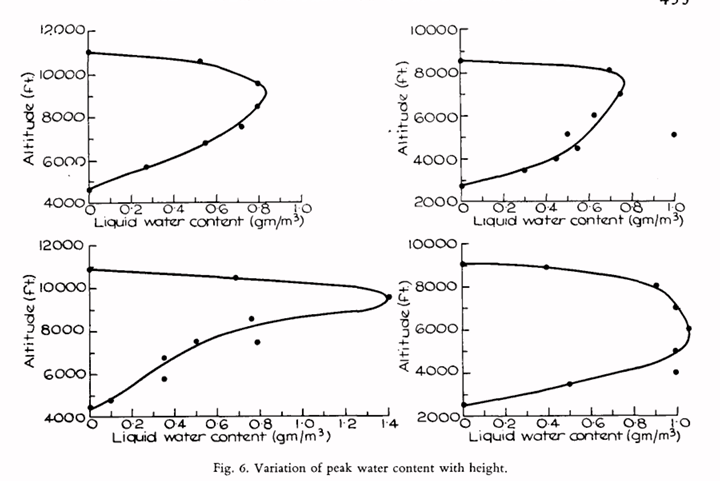

### 2a) Plot Kohler curves for 0.0, 10-19, and 10-17 kg of sodium chloride, which forms 2 ions. Use an osmotic coefficient of 1, a temperature of 20°C, and water density of 1000 kg/m-3. Your plot should range from r=10-5 to 10-3 cm, with a logarithmic x axis and supersaturations from -0.2 to 0.5 percent. See plt.semilogx.

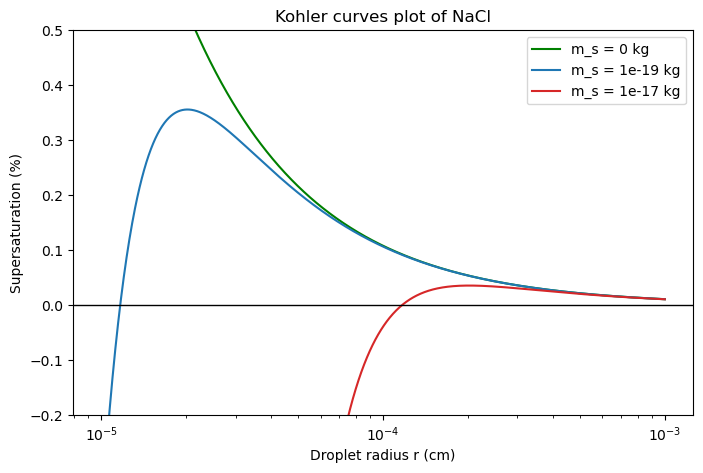

In [190]:
import matplotlib.pyplot as plt

M_s = 0.05844 * units('kg/mol')
ion_count = 2
phi_s = 1.0
T_C = 20.0
T_K = (T_C + 273.15) * units.kelvin

def sfc_tension(T):
    """ PPK p. 130, sfc tension of water and air (or water and vapor) 
        Temperature is in degrees Celsius.
    """
    sigma_wa = 76.10 - 0.155*T  # ergs per square cm
    JperErg = 1.0e-7
    m2percm2 = (0.01)**2.0
    converter = JperErg / m2percm2 # to Joules per square meter
    return sigma_wa*converter

sigma = sfc_tension(T_C) * units('N/m')

def kohler(radii, solute_mass, solute_molar_mass, ion_count, phi_s, T):
    A = 2*sigma*M_l / (R_star*T*rho_l)
    B = (ion_count*phi_s*solute_mass*M_l) / (solute_molar_mass*(4/3)*np.pi*rho_l)
    return A/radii - B/radii**3, A, B

radii = np.logspace(-7, -5, 1000) * units.meter
masses = [0.0, 1e-19, 1e-17]
colors = ['green', 'tab:blue', 'tab:red']
r_cm = radii.to('cm').magnitude

fig, ax = plt.subplots(figsize=(8, 5))
for m, c in zip(masses, colors):
    S, A, B = kohler(radii, m * units.kg, M_s, ion_count, phi_s, T_K)
    ax.semilogx(r_cm, S.to('dimensionless').magnitude*100, color=c, label=f'm_s = {m:g} kg')

ax.set_ylim(-0.2, 0.5)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Droplet radius r (cm)')
ax.set_ylabel('Supersaturation (%)')
ax.set_title('Kohler curves plot of NaCl')
ax.legend()
plt.show()

### 2b) Confirmation of the correct expression for the critical radius:

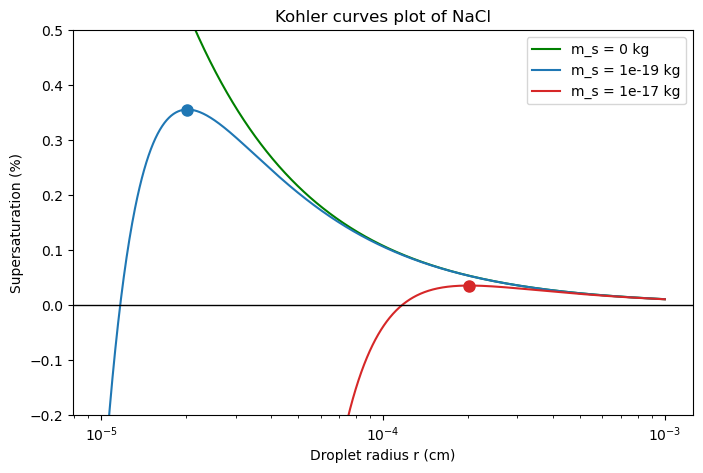

In [193]:
for m, c in zip(masses, colors):
    if m > 0:
        S, A, B = kohler(radii, m * units.kg, M_s, ion_count, phi_s, T_K)
        a_c = np.sqrt(3*B/A).to('cm').magnitude
        S_c = np.sqrt(4*A**3/(27*B)).to('dimensionless').magnitude
        ax.plot(a_c, S_c*100, 'o', color=c, ms=8)
fig

Sources used for coding/plot/LaTeX assistance:
- Google
- Claude
- Classmates